In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('calls_data.csv')

In [5]:
df

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,80548049535,2025-06-01 16:44,Outbound,00:00:00,NaN,Kevin Nuesi
1,80547821455,2025-06-01 16:45,Outbound,00:00:00,NaN,Kevin Nuesi
2,80550594447,2025-06-01 20:15,Inbound,00:00:00,NaN,NaN
3,80566407069,2025-06-02 09:22,NaN,NaN,NaN,Robin Stoehr
4,80569306473,2025-06-02 09:52,NaN,NaN,NaN,Robin Stoehr
...,...,...,...,...,...,...
100375,100163907155,2025-12-31 18:03,Outbound,00:00:07,NaN,David Banister
100376,100161410935,2025-12-31 18:10,Outbound,00:00:02,NaN,Tyler Jury
100377,100123945791,2025-12-31 18:10,Outbound,00:00:02,NaN,Tyler Jury
100378,100158807052,2025-12-31 18:38,Outbound,00:00:07,NaN,Jerry Guadiana


In [7]:
df1 = df.drop(columns= ['hs_call_outcome', 'Record ID'])

In [9]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [11]:
df2=df1.copy()

In [13]:
df2['date'] = df2['Activity date'].dt.date

In [15]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN,2025-06-01
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr,2025-06-02
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr,2025-06-02


In [17]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [19]:
daily_calls.columns = ["ds", "y"] 

In [21]:
daily_calls

,ds,y
0,2025-06-01,3
1,2025-06-02,458
2,2025-06-03,578
3,2025-06-04,692
4,2025-06-05,398
...,...,...
208,2025-12-27,31
209,2025-12-28,42
210,2025-12-29,512
211,2025-12-30,571


In [23]:
from prophet import Prophet

In [25]:
model = Prophet()
model.fit(daily_calls)

10:28:40 - cmdstanpy - INFO - Chain [1] start processing
10:28:40 - cmdstanpy - INFO - Chain [1] done processing


In [26]:
from prophet.diagnostics import cross_validation, performance_metrics

In [28]:
df_cv = cross_validation(
    model,
    initial='140 days',   # ~65%
    period='14 days',     # step between folds
    horizon='30 days'     # forecast window
)

  0%|          | 0/4 [00:00<?, ?it/s]

10:28:41 - cmdstanpy - INFO - Chain [1] start processing
10:28:41 - cmdstanpy - INFO - Chain [1] done processing
10:28:41 - cmdstanpy - INFO - Chain [1] start processing
10:28:41 - cmdstanpy - INFO - Chain [1] done processing
10:28:41 - cmdstanpy - INFO - Chain [1] start processing
10:28:41 - cmdstanpy - INFO - Chain [1] done processing
10:28:41 - cmdstanpy - INFO - Chain [1] start processing
10:28:41 - cmdstanpy - INFO - Chain [1] done processing


In [30]:
df_pref = performance_metrics(df_cv)
df_pref.head(10)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,3 days,10110.758710,100.552269,85.217043,0.118632,0.086271,0.117592,0.833333
1,4 days,16476.492834,128.360792,106.937095,0.141076,0.118833,0.152341,0.750000
2,5 days,15054.897563,122.698401,94.833790,0.286837,0.180414,0.298605,0.750000
3,6 days,12672.601147,112.572648,81.332385,1.109521,0.381360,0.543682,0.833333
4,7 days,6038.332819,77.706710,63.231288,1.083992,0.333634,0.512243,1.000000
5,8 days,7953.462157,89.182185,75.074504,0.933851,0.161137,0.362169,0.916667
6,9 days,9872.328568,99.359592,86.176264,0.106581,0.138674,0.111830,0.916667
7,10 days,48523.564172,220.280649,140.993600,4.156161,0.154664,0.272688,0.750000
8,11 days,58108.462514,241.056969,170.475590,4.236322,0.160588,0.337834,0.666667
9,12 days,55951.356966,236.540392,157.041990,4.777421,0.247733,0.545670,0.666667


In [31]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(20)

,ds,yhat,yhat_lower,yhat_upper
223,2026-01-11,5.769787,-177.160734,181.945646
224,2026-01-12,647.105427,466.540793,809.735413
225,2026-01-13,701.684434,531.761143,882.278825
226,2026-01-14,637.880085,459.515492,819.779778
227,2026-01-15,588.278535,408.735111,755.970640
228,2026-01-16,528.653030,347.289983,702.574828
229,2026-01-17,5.870510,-156.265842,190.344415
230,2026-01-18,1.191577,-165.621642,178.910181
231,2026-01-19,642.527217,477.416499,818.875192
232,2026-01-20,697.106224,519.803129,857.099796


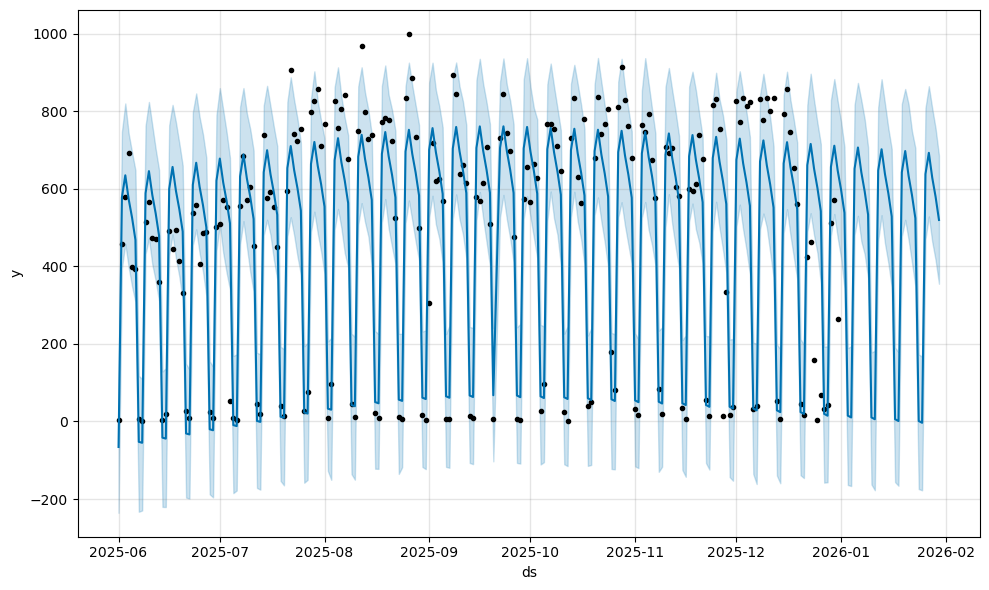

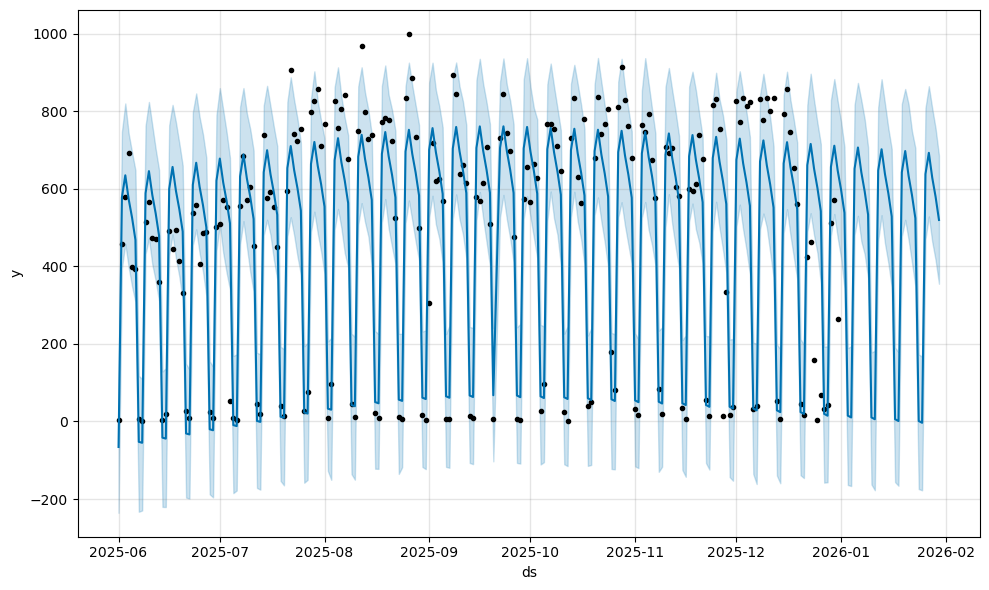

In [34]:
model.plot(forecast)

In [36]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr


In [37]:
df3 =df.copy()

In [41]:
df3['Call duration'] = (
    pd.to_timedelta(df2['Call duration'], errors='coerce')
    .dt.total_seconds()/60
)

In [43]:
df3.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,80548049535,2025-06-01 16:44,Outbound,0.0,NaN,Kevin Nuesi
1,80547821455,2025-06-01 16:45,Outbound,0.0,NaN,Kevin Nuesi
2,80550594447,2025-06-01 20:15,Inbound,0.0,NaN,NaN
3,80566407069,2025-06-02 09:22,NaN,NaN,NaN,Robin Stoehr
4,80569306473,2025-06-02 09:52,NaN,NaN,NaN,Robin Stoehr


In [45]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 100380 entries, 0 to 100379
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Record ID             100380 non-null  int64  
 1   Activity date         100380 non-null  str    
 2   Call direction        95140 non-null   str    
 3   Call duration         94927 non-null   float64
 4   hs_call_outcome       0 non-null       float64
 5   Activity assigned to  94026 non-null   str    
dtypes: float64(2), int64(1), str(3)
memory usage: 8.0 MB


In [47]:
df3['Activity date'] = pd.to_datetime(df3['Activity date'])

In [49]:
df3["ds"] = df3['Activity date'].dt.date
df3["ds"] = pd.to_datetime(df3["ds"])

In [51]:
daily = (
    df3.groupby("ds")
    .agg(
        call_count = ("Record ID", "count"),
        total_duration=("Call duration", "sum"),
        avg_duration=("Call duration", "mean")
    )
    .reset_index()
)

In [53]:
daily.head()

,ds,call_count,total_duration,avg_duration
0,2025-06-01,3,0.000000,0.000000
1,2025-06-02,458,1236.666667,2.902973
2,2025-06-03,578,1255.116667,2.404438
3,2025-06-04,692,1322.366667,2.072675
4,2025-06-05,398,1106.483333,2.982435


In [55]:
daily['dayofweek'] = daily['ds'].dt.dayofweek
daily['month'] = daily['ds'].dt.month
daily['weekofyear'] = daily['ds'].dt.isocalendar().week.astype(int)

In [57]:
daily.head()

,ds,call_count,total_duration,avg_duration,dayofweek,month,weekofyear
0,2025-06-01,3,0.000000,0.000000,6,6,22
1,2025-06-02,458,1236.666667,2.902973,0,6,23
2,2025-06-03,578,1255.116667,2.404438,1,6,23
3,2025-06-04,692,1322.366667,2.072675,2,6,23
4,2025-06-05,398,1106.483333,2.982435,3,6,23


In [59]:
daily = daily.sort_values('ds').reset_index(drop=True)

In [61]:
daily['lag_1'] = daily["call_count"].shift(1)
daily['lag_7'] = daily['call_count'].shift(7)
daily['lag_14'] = daily['call_count'].shift(14)
daily['lag_21'] = daily['call_count'].shift(21)
daily['lag_28'] = daily['call_count'].shift(28)

In [63]:
daily.tail()

,ds,call_count,total_duration,avg_duration,dayofweek,month,weekofyear,lag_1,lag_7,lag_14,lag_21,lag_28
208,2025-12-27,31,68.116667,2.197312,5,12,52,67.0,44.0,54.0,31.0,16.0
209,2025-12-28,42,79.416667,1.890873,6,12,52,31.0,17.0,7.0,39.0,38.0
210,2025-12-29,512,1033.300000,2.054274,0,12,1,42.0,425.0,793.0,832.0,827.0
211,2025-12-30,571,1408.983333,2.471901,1,12,1,512.0,463.0,858.0,778.0,771.0
212,2025-12-31,265,608.666667,2.296855,2,12,1,571.0,158.0,747.0,835.0,833.0


In [65]:
daily['roll_mean_7'] = daily['call_count'].rolling(7).mean()
daily['roll_std_7']= daily['call_count'].rolling(7).std()

daily['roll_mean_14']= daily['call_count'].rolling(14).mean()
daily['roll_std_14'] = daily['call_count'].rolling(14).std()

In [67]:
daily

,ds,call_count,total_duration,avg_duration,dayofweek,month,weekofyear,lag_1,lag_7,lag_14,lag_21,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14
0,2025-06-01,3,0.000000,0.000000,6,6,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-06-02,458,1236.666667,2.902973,0,6,23,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-06-03,578,1255.116667,2.404438,1,6,23,458.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-06-04,692,1322.366667,2.072675,2,6,23,578.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-06-05,398,1106.483333,2.982435,3,6,23,692.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,2025-12-27,31,68.116667,2.197312,5,12,52,67.0,44.0,54.0,31.0,16.0,166.285714,196.701732,344.785714,331.379675
209,2025-12-28,42,79.416667,1.890873,6,12,52,31.0,17.0,7.0,39.0,38.0,169.857143,193.744186,347.285714,328.756966
210,2025-12-29,512,1033.300000,2.054274,0,12,1,42.0,425.0,793.0,832.0,827.0,182.285714,214.516289,327.214286,307.331487
211,2025-12-30,571,1408.983333,2.471901,1,12,1,512.0,463.0,858.0,778.0,771.0,197.714286,240.393923,306.714286,277.308334


In [69]:
daily['call_count'].min()

1

In [71]:
daily['call_count']

0        3
1      458
2      578
3      692
4      398
      ... 
208     31
209     42
210    512
211    571
212    265
Name: call_count, Length: 213, dtype: int64

In [73]:
daily.corr()

,ds,call_count,total_duration,avg_duration,dayofweek,month,weekofyear,lag_1,lag_7,lag_14,lag_21,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14
ds,1.000000,0.069672,0.053442,-0.105161,-0.004815,0.989763,0.786252,0.075439,0.123605,0.161793,0.153882,0.142734,0.243874,0.343621,0.391340,0.538602
call_count,0.069672,1.000000,0.959202,-0.060957,-0.768032,0.077702,0.091737,0.407931,0.836367,0.809463,0.748913,0.758967,0.305321,0.229390,0.262552,0.172789
total_duration,0.053442,0.959202,1.000000,0.016540,-0.763348,0.066353,0.072322,0.401735,0.820530,0.796652,0.758684,0.757460,0.228315,0.157640,0.189716,0.095584
avg_duration,-0.105161,-0.060957,0.016540,1.000000,0.021148,-0.103304,-0.092603,0.040927,-0.035300,-0.040243,-0.032068,-0.002654,-0.143970,-0.132764,-0.173548,-0.213891
dayofweek,-0.004815,-0.768032,-0.763348,0.021148,1.000000,-0.009330,0.040631,-0.054006,-0.753073,-0.734631,-0.710978,-0.676149,-0.003967,0.006388,-0.009150,0.013168
month,0.989763,0.077702,0.066353,-0.103304,-0.009330,1.000000,0.792871,0.080978,0.130611,0.165592,0.155695,0.147784,0.252299,0.359852,0.408141,0.558207
weekofyear,0.786252,0.091737,0.072322,-0.092603,0.040631,0.792871,1.000000,0.093932,0.167695,0.083226,0.062928,0.044177,0.437864,0.442259,0.536314,0.556133
lag_1,0.075439,0.407931,0.401735,0.040927,-0.054006,0.080978,0.093932,1.000000,0.361583,0.370964,0.347420,0.420910,0.322159,0.248736,0.268487,0.183591
lag_7,0.123605,0.836367,0.820530,-0.035300,-0.753073,0.130611,0.167695,0.361583,1.000000,0.847905,0.842615,0.783718,0.198969,0.206776,0.270530,0.214212
lag_14,0.161793,0.809463,0.796652,-0.040243,-0.734631,0.165592,0.083226,0.370964,0.847905,1.000000,0.861384,0.859589,0.108252,0.110833,0.164712,0.177112


In [75]:
daily = pd.read_csv('daily.csv')

In [77]:
train = daily[daily["ds"] < "2025-12-1"]
test = daily[daily["ds"] >= '2025-12-1']

In [79]:
features = [
    "lag_1","lag_7","lag_21","lag_28","roll_mean_7","roll_mean_14","dayofweek"
]

In [81]:
target = "call_count"

In [83]:
from xgboost import XGBRegressor

model = XGBRegressor(
    objective="count:poisson",
    n_estimators=320,
    learning_rate=0.06,
    max_depth=2,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

In [84]:
model.fit(train[features], train[target])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.06, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=320,
             n_jobs=None, num_parallel_tree=None, ...)

In [85]:
preds = model.predict(test[features])

In [86]:
import joblib

In [87]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test[target], preds)
print("MAE:", mae)

MAE: 77.60993456504714


In [89]:
test[target]

20      26
21       9
22     537
23     559
24     406
      ... 
204     31
205     42
206    512
207    571
208    265
Name: call_count, Length: 71, dtype: int64

In [95]:
preds

array([ 13.184316 ,   6.4398727, 538.19293  , 559.7551   , 540.19916  ,
       489.50873  , 494.29883  ,  10.781732 ,  13.208129 , 608.0759   ,
       624.41235  , 627.56775  , 664.8686   , 699.60486  , 640.31934  ,
        28.892874 ,  15.346342 , 757.14026  , 773.4188   , 815.80585  ,
       758.2795   , 732.98     , 673.60974  ,  26.88254  ,  18.676493 ,
       713.4098   , 783.78033  , 734.63885  , 719.2455   , 709.04034  ,
        28.139671 ,  17.89188  , 491.6911   , 755.54224  , 854.5875   ,
       812.65015  , 666.634    ,  42.85285  ,  16.999716 , 542.71155  ,
       676.1498   , 732.5953   , 743.43365  , 731.28644  , 698.67505  ,
        58.28214  ,  48.703785 , 826.3356   , 842.69867  , 806.75793  ,
       803.9335   , 780.58765  , 629.07056  ,  38.43301  ,  17.882536 ,
       756.33417  , 775.99915  , 743.81305  , 527.1326   ,  16.884672 ,
         9.056974 ,  19.169893 , 669.59357  , 676.0576   , 578.6061   ,
       406.08838  ,  13.800263 ,   8.124824 , 491.96503  , 522.0

In [97]:
daily["call_count"].mean()

478.4976076555024

In [99]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

In [101]:
model = XGBRegressor(
    objective="count:poisson",
    random_state=42,
)
tscv = TimeSeriesSplit(n_splits=3)

In [103]:
param_grid = {
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.03, 0.05,0.06, 0.07, 0.1],
    "n_estimators": [100, 200, 300,320,325, 400],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

In [105]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,   
    cv=tscv,
    scoring="neg_mean_squared_error",  
    n_jobs=-1,            
)

grid_search.fit(train[features], train[target])

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9],
                         'learning_rate': [0.03, 0.05, 0.06, 0.07, 0.1],
                         'max_depth': [2, 3, 4, 5],
                         'n_estimators': [100, 200, 300, 320, 325, 400],
                         'subsample': [0.7, 0.8, 0.9]},
             scoring='neg_mean_squared_error')

In [106]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Best Parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.9}
Best Score: -11079.557630025927


In [107]:
y_pred = best_model.predict(test[features])

In [108]:
mae = mean_absolute_error(test[target], y_pred)
print("MAE:", mae)

MAE: 81.0600643963881


In [109]:
test[target]

20      26
21       9
22     537
23     559
24     406
      ... 
204     31
205     42
206    512
207    571
208    265
Name: call_count, Length: 71, dtype: int64

In [110]:
y_pred

array([ 16.157135,  13.498833, 532.4123  , 541.4705  , 537.007   ,
       490.22186 , 527.08563 ,  15.74651 ,  18.598526, 594.91113 ,
       603.965   , 621.27075 , 685.62915 , 697.20703 , 646.2128  ,
        32.17302 ,  23.22948 , 748.26154 , 774.03125 , 792.9327  ,
       758.6752  , 734.6613  , 668.02295 ,  33.28952 ,  28.122032,
       720.5592  , 769.46    , 758.71313 , 731.20276 , 693.8623  ,
        33.10677 ,  26.76433 , 420.29745 , 730.6977  , 809.40704 ,
       771.3795  , 678.5369  ,  51.207397,  24.964008, 671.7926  ,
       677.77576 , 723.9674  , 737.5391  , 725.2109  , 706.7204  ,
        51.22591 ,  46.8725  , 791.5734  , 824.4519  , 810.53174 ,
       788.5517  , 767.64526 , 630.33167 ,  33.291298,  25.9459  ,
       718.4273  , 749.65436 , 754.6162  , 543.23065 ,  19.604156,
        16.227072,  28.687426, 677.778   , 660.51544 , 581.3789  ,
       445.7066  ,  18.69217 ,  16.48284 , 519.37164 , 521.2739  ,
       574.1693  ], dtype=float32)

In [111]:
da = pd.read_csv('daily.csv')

In [112]:
da.head()

,ds,call_count,total_duration,avg_duration,dayofweek,month,weekofyear,lag_1,lag_7,lag_14,lag_21,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14
0,01-06-2025,3,0.000000,0.000000,6,6,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,02-06-2025,458,1236.666667,2.902973,0,6,23,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,03-06-2025,578,1255.116667,2.404438,1,6,23,458.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,04-06-2025,692,1322.366667,2.072675,2,6,23,578.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,05-06-2025,398,1106.483333,2.982435,3,6,23,692.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [113]:
da = da.drop(columns=['total_duration', 'avg_duration'])

In [114]:
da = da.dropna()

In [115]:
da

,ds,call_count,dayofweek,month,weekofyear,lag_1,lag_7,lag_14,lag_21,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14
28,29-06-2025,9,6,6,26,25.0,9.0,20.0,1.0,3.0,358.857143,238.478810,337.214286,217.396900
29,30-06-2025,501,0,6,27,9.0,537.0,491.0,515.0,458.0,353.714286,234.349251,337.928571,217.956758
30,01-07-2025,509,1,7,27,501.0,559.0,445.0,566.0,578.0,346.571429,227.717557,342.500000,221.024799
31,02-07-2025,571,2,7,27,509.0,406.0,493.0,472.0,692.0,370.142857,242.926209,348.071429,226.036574
32,03-07-2025,553,3,7,27,571.0,487.0,413.0,470.0,398.0,379.571429,249.411880,358.071429,232.144340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,27-12-2025,31,5,12,52,67.0,44.0,54.0,31.0,16.0,166.285714,196.701732,344.785714,331.379675
205,28-12-2025,42,6,12,52,31.0,17.0,7.0,39.0,38.0,169.857143,193.744186,347.285714,328.756966
206,29-12-2025,512,0,12,1,42.0,425.0,793.0,832.0,827.0,182.285714,214.516289,327.214286,307.331487
207,30-12-2025,571,1,12,1,512.0,463.0,858.0,778.0,771.0,197.714286,240.393923,306.714286,277.308334


In [116]:
daily_calls.head()

,ds,y
0,2025-06-01,3
1,2025-06-02,458
2,2025-06-03,578
3,2025-06-04,692
4,2025-06-05,398


In [117]:
daily_calls['ds'] = pd.to_datetime(daily_calls['ds'], errors='coerce')

In [118]:
daily_calls['dayofweek'] = daily_calls['ds'].dt.dayofweek
daily_calls['month'] = daily_calls['ds'].dt.month
daily_calls['weekofyear'] = daily_calls['ds'].dt.isocalendar().week.astype(int)

In [119]:
daily_calls['lag_1'] = daily_calls["y"].shift(1)
daily_calls['lag_7'] = daily_calls['y'].shift(7)
daily_calls['lag_14'] = daily_calls['y'].shift(14)
daily_calls['lag_21'] = daily_calls['y'].shift(21)
daily_calls['lag_28'] = daily_calls['y'].shift(28)

In [120]:
daily_calls['roll_mean_7'] = daily_calls['y'].rolling(7).mean()
daily_calls['roll_std_7']= daily_calls['y'].rolling(7).std()

daily_calls['roll_mean_14']= daily_calls['y'].rolling(14).mean()
daily_calls['roll_std_14'] = daily_calls['y'].rolling(14).std()

In [121]:
import holidays

In [122]:
us_holidays_2025 = holidays.US(years=[2025])

In [123]:
us_holidays_2025

{datetime.date(2025, 1, 1): "New Year's Day", datetime.date(2025, 5, 26): 'Memorial Day', datetime.date(2025, 6, 19): 'Juneteenth National Independence Day', datetime.date(2025, 7, 4): 'Independence Day', datetime.date(2025, 9, 1): 'Labor Day', datetime.date(2025, 11, 27): 'Thanksgiving Day', datetime.date(2025, 12, 25): 'Christmas Day', datetime.date(2025, 1, 20): 'Martin Luther King Jr. Day', datetime.date(2025, 2, 17): "Washington's Birthday", datetime.date(2025, 10, 13): 'Columbus Day', datetime.date(2025, 11, 11): 'Veterans Day'}

In [124]:
daily_calls['is_us_holiday'] = (
    daily_calls['ds'].dt.date.isin(us_holidays_2025)
).astype(int)

In [125]:
daily_calls.head()

,ds,y,dayofweek,month,weekofyear,lag_1,lag_7,lag_14,lag_21,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,is_us_holiday
0,2025-06-01,3,6,6,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2025-06-02,458,0,6,23,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2025-06-03,578,1,6,23,458.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2025-06-04,692,2,6,23,578.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2025-06-05,398,3,6,23,692.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [126]:
daily_calls.corr()

,ds,y,dayofweek,month,weekofyear,lag_1,lag_7,lag_14,lag_21,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,is_us_holiday
ds,1.000000,0.069672,-0.004815,0.989763,0.786252,0.075439,0.123605,0.161793,0.153882,0.142734,0.243874,0.343621,0.391340,0.538602,0.034313
y,0.069672,1.000000,-0.768032,0.077702,0.091737,0.407931,0.836367,0.809463,0.748913,0.758967,0.305321,0.229390,0.262552,0.172789,-0.090302
dayofweek,-0.004815,-0.768032,1.000000,-0.009330,0.040631,-0.054006,-0.753073,-0.734631,-0.710978,-0.676149,-0.003967,0.006388,-0.009150,0.013168,-0.089477
month,0.989763,0.077702,-0.009330,1.000000,0.792871,0.080978,0.130611,0.165592,0.155695,0.147784,0.252299,0.359852,0.408141,0.558207,0.039000
weekofyear,0.786252,0.091737,0.040631,0.792871,1.000000,0.093932,0.167695,0.083226,0.062928,0.044177,0.437864,0.442259,0.536314,0.556133,0.048023
lag_1,0.075439,0.407931,-0.054006,0.080978,0.093932,1.000000,0.361583,0.370964,0.347420,0.420910,0.322159,0.248736,0.268487,0.183591,-0.052824
lag_7,0.123605,0.836367,-0.753073,0.130611,0.167695,0.361583,1.000000,0.847905,0.842615,0.783718,0.198969,0.206776,0.270530,0.214212,0.113151
lag_14,0.161793,0.809463,-0.734631,0.165592,0.083226,0.370964,0.847905,1.000000,0.861384,0.859589,0.108252,0.110833,0.164712,0.177112,0.085681
lag_21,0.153882,0.748913,-0.710978,0.155695,0.062928,0.347420,0.842615,0.861384,1.000000,0.854743,0.024732,0.060001,0.108118,0.124473,0.120795
lag_28,0.142734,0.758967,-0.676149,0.147784,0.044177,0.420910,0.783718,0.859589,0.854743,1.000000,0.065909,0.068340,0.085407,0.079185,-0.002874


In [127]:
train = daily_calls[daily_calls["ds"] < "2025-12-1"]
test = daily_calls[daily_calls["ds"] >= '2025-12-1']

In [128]:
features = [
    "lag_1","lag_7","lag_21","lag_28","roll_mean_7","roll_mean_14","dayofweek",'is_us_holiday'
]

In [129]:
target = "y"

In [130]:
from xgboost import XGBRegressor

model = XGBRegressor(
    objective="count:poisson",
    n_estimators=320,
    learning_rate=0.06,
    max_depth=2,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

In [131]:
model.fit(train[features], train[target])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.06, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=320,
             n_jobs=None, num_parallel_tree=None, ...)

In [132]:
preds = model.predict(test[features])

In [133]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test[target], preds)
print("MAE:", mae)

MAE: 113.55242966067406


In [134]:
test[target]

182    827
183    771
184    833
185    813
186    824
187     31
188     39
189    832
190    778
191    835
192    801
193    834
194     54
195      7
196    793
197    858
198    747
199    653
200    561
201     44
202     17
203    425
204    463
205    158
206      3
207     67
208     31
209     42
210    512
211    571
212    265
Name: y, dtype: int64

In [135]:
y_pred

array([ 16.157135,  13.498833, 532.4123  , 541.4705  , 537.007   ,
       490.22186 , 527.08563 ,  15.74651 ,  18.598526, 594.91113 ,
       603.965   , 621.27075 , 685.62915 , 697.20703 , 646.2128  ,
        32.17302 ,  23.22948 , 748.26154 , 774.03125 , 792.9327  ,
       758.6752  , 734.6613  , 668.02295 ,  33.28952 ,  28.122032,
       720.5592  , 769.46    , 758.71313 , 731.20276 , 693.8623  ,
        33.10677 ,  26.76433 , 420.29745 , 730.6977  , 809.40704 ,
       771.3795  , 678.5369  ,  51.207397,  24.964008, 671.7926  ,
       677.77576 , 723.9674  , 737.5391  , 725.2109  , 706.7204  ,
        51.22591 ,  46.8725  , 791.5734  , 824.4519  , 810.53174 ,
       788.5517  , 767.64526 , 630.33167 ,  33.291298,  25.9459  ,
       718.4273  , 749.65436 , 754.6162  , 543.23065 ,  19.604156,
        16.227072,  28.687426, 677.778   , 660.51544 , 581.3789  ,
       445.7066  ,  18.69217 ,  16.48284 , 519.37164 , 521.2739  ,
       574.1693  ], dtype=float32)